# Lecture 4 — Class Exercise
## Scatter & Bubble Charts: Gapminder

> **Push to:** `week04/lecture04_exercise.ipynb`

**Rules:**
1. Colour used **sparingly** — one categorical variable, no rainbow
2. If showing all continents, either use accessible palette OR grey all + highlight one
3. `size_max` set when using bubble size
4. Log scale for GDP per capita
5. Insight title

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [2]:
# explore
print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

## Task 1 — Scatter: life expectancy change over time

**What to build:** A scatter showing **GDP per capita vs life expectancy** for **two years** (2000 and 2007) to show how both moved — use **colour for year** (just 2 colours), **one continent only**.

Choose any continent except Africa (that was the example). Highlight the change direction.

> 💡 Filter: `df.loc[df['continent'] == 'YOUR_CHOICE']` then filter years


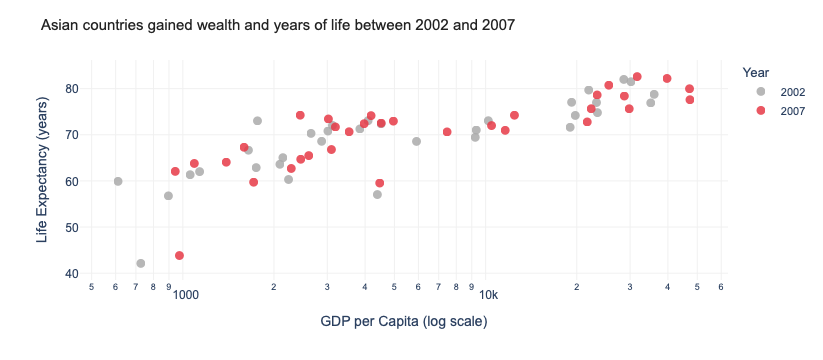

In [3]:
# Task 1 — Scatter: GDP per capita vs Life Expectancy (Asia, 2002 vs 2007)

# Filter to Asia, two years
asia = df[(df['continent'] == 'Asia') & (df['year'].isin([2002, 2007]))].copy()
asia['year'] = asia['year'].astype(str)  # treat year as category for colour

COLOR_MAP = {'2002': '#AAAAAA', '2007': '#E63946'}

fig = px.scatter(
    asia,
    x='gdpPercap',
    y='lifeExp',
    color='year',
    color_discrete_map=COLOR_MAP,
    hover_name='country',
    log_x=True,
    labels={
        'gdpPercap': 'GDP per Capita (log scale)',
        'lifeExp':   'Life Expectancy (years)',
        'year':      'Year'
    }
)

fig.update_traces(marker=dict(size=9, opacity=0.85))

fig.update_layout(
    title=dict(
        text="Asian countries gained wealth and years of life between 2002 and 2007",
        font=dict(family='Arial', size=15, color='#222222')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial'),
    xaxis=dict(
        showgrid=True, gridcolor='#F0F0F0',
        showline=False, zeroline=False
    ),
    yaxis=dict(
        showgrid=True, gridcolor='#F0F0F0',
        showline=False, zeroline=False
    ),
    legend=dict(
        title='Year',
        font=dict(family='Arial', size=11)
    )
)

fig.show()

## Task 2 — Bubble chart: tell a story

**What to build:** A bubble chart (full 2007 dataset, all countries) where:
- x = GDP per capita (log scale)
- y = life expectancy
- size = population
- colour = ONE continent highlighted (your choice), all others grey
- At least one annotation explaining the highlighted group's story

> This is the grey-and-highlight technique applied to a bubble chart.


In [ ]:
# Task 2 — Bubble chart: grey + highlight (Europe highlighted)

data_2007 = df[df['year'] == 2007].copy()

HIGHLIGHT     = 'Europe'
HIGHLIGHT_COLOR = '#457B9D'
GREY          = '#DDDDDD'

fig = go.Figure()

# Grey bubbles — all other continents
others = data_2007[data_2007['continent'] != HIGHLIGHT]
fig.add_trace(go.Scatter(
    x=others['gdpPercap'],
    y=others['lifeExp'],
    mode='markers',
    marker=dict(
        size=others['pop'] / 1_500_000,
        sizemode='area',
        sizeref=2,
        sizemin=4,
        color=GREY,
        opacity=0.7
    ),
    text=others['country'],
    hovertemplate='%{text}<br>GDP: $%{x:,.0f}<br>Life Exp: %{y:.1f} yrs<extra></extra>',
    showlegend=False
))

# Highlighted bubbles — Europe
europe = data_2007[data_2007['continent'] == HIGHLIGHT]
fig.add_trace(go.Scatter(
    x=europe['gdpPercap'],
    y=europe['lifeExp'],
    mode='markers',
    marker=dict(
        size=europe['pop'] / 1_500_000,
        sizemode='area',
        sizeref=2,
        sizemin=4,
        color=HIGHLIGHT_COLOR,
        opacity=0.85
    ),
    text=europe['country'],
    hovertemplate='%{text}<br>GDP: $%{x:,.0f}<br>Life Exp: %{y:.1f} yrs<extra></extra>',
    showlegend=False
))

# Annotation
fig.add_annotation(
    x=3.9, y=79,  # log10(~8000)
    text="<b>Europe</b><br>High wealth,<br>long lives",
    showarrow=True,
    arrowhead=2,
    arrowcolor=HIGHLIGHT_COLOR,
    ax=60, ay=-40,
    font=dict(family='Arial', size=11, color=HIGHLIGHT_COLOR),
    align='left'
)

fig.update_layout(
    title=dict(
        text="European countries cluster at high wealth and long life expectancy in 2007",
        font=dict(family='Arial', size=15, color='#222222')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial'),
    xaxis=dict(
        type='log',
        title='GDP per Capita (log scale)',
        showgrid=True, gridcolor='#F0F0F0',
        showline=False, zeroline=False
    ),
    yaxis=dict(
        title='Life Expectancy (years)',
        showgrid=True, gridcolor='#F0F0F0',
        showline=False, zeroline=False
    )
)

fig.show()